In [1]:
import pandas as pd
import seaborn as sns
import pandas as pd

In [2]:
insurance_data = pd.read_csv('insurance.csv')

<Axes: xlabel='bmi', ylabel='charges'>

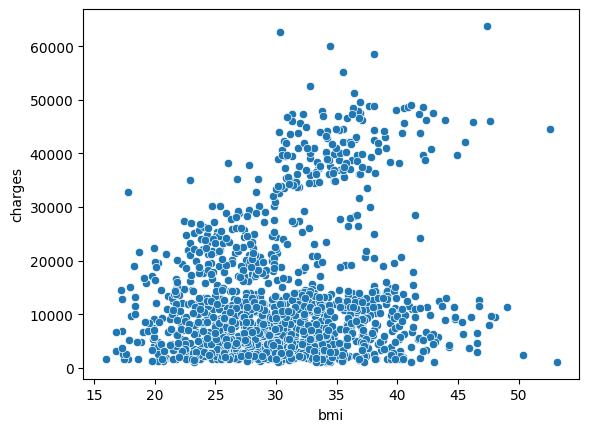

In [3]:
sns.scatterplot(data=insurance_data, x='bmi', y='charges')

<Axes: xlabel='bmi', ylabel='charges'>

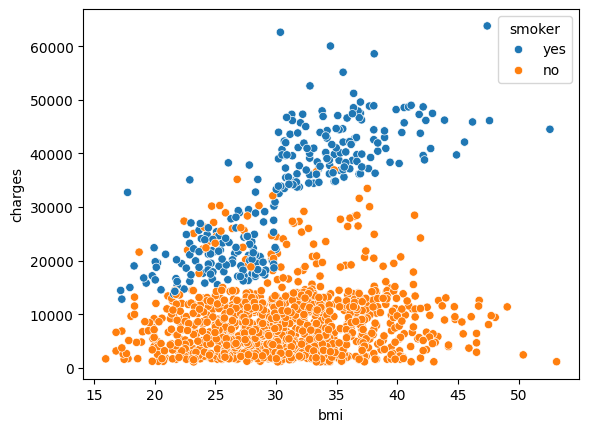

In [4]:
sns.scatterplot(data=insurance_data, x='bmi', y='charges', hue = insurance_data['smoker'])

In [5]:
X = insurance_data.drop(columns = ['charges','region'])
y = insurance_data['charges']

X['sex'] = X['sex'].map({'male':0, 'female':1})
X['smoker'] = X['smoker'].map({'yes':1, 'no':0})

In [6]:
X.head()

,age,sex,bmi,children,smoker
0,19,1,27.900,0,1
1,18,0,33.770,1,0
2,28,0,33.000,3,0
3,33,0,22.705,0,0
4,32,0,28.880,0,0


In [7]:
#Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [8]:
X_train.head()

,age,sex,bmi,children,smoker
560,46,1,19.95,2,0
1285,47,1,24.32,0,0
1142,52,1,24.86,0,0
969,39,1,34.32,5,0
486,54,1,21.47,3,0


In [9]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [10]:
y_pred = model.predict(X_test)

In [11]:
y_pred

array([ 8554.81711589,  6973.58746745, 36798.60416104,  9417.88282303,
       26871.68031081, 11097.38383938,   145.27608963, 16746.1683771 ,
         747.53414191, 11153.67590722, 28518.15016561,  9292.18345421,
        5460.51975119, 38510.48013003, 40359.30938604, 37223.40538064,
       15316.56711945, 36047.50032223,  9326.29049907, 31400.1559532 ,
        4269.64414373, 10464.66374097,  2719.9260555 ,  6579.53742551,
       11232.00255515, 12472.06793446, 14807.11281089,  6066.19283362,
        9535.69029723,  2377.6983797 ,  9475.05690885, 12963.23366722,
        4706.09057393,  3414.674504  ,  4815.64981654, 12484.17176954,
        2359.13614479,  9161.02061228, 33238.67621442, 32743.41702445,
        4274.58967205,  4229.5442107 , 14435.36485176, 11384.66898976,
        8925.70468583, 12480.09178788,  5154.45787816,  3554.10047649,
       35649.60942684,  9276.25523701, 15971.35991397,  2552.75200479,
       12162.99980138,  1062.65132285, 13551.43771934, 12103.65505529,
      

In [12]:
X_pred = model.predict(X_test)

In [13]:
X_pred

array([ 8554.81711589,  6973.58746745, 36798.60416104,  9417.88282303,
       26871.68031081, 11097.38383938,   145.27608963, 16746.1683771 ,
         747.53414191, 11153.67590722, 28518.15016561,  9292.18345421,
        5460.51975119, 38510.48013003, 40359.30938604, 37223.40538064,
       15316.56711945, 36047.50032223,  9326.29049907, 31400.1559532 ,
        4269.64414373, 10464.66374097,  2719.9260555 ,  6579.53742551,
       11232.00255515, 12472.06793446, 14807.11281089,  6066.19283362,
        9535.69029723,  2377.6983797 ,  9475.05690885, 12963.23366722,
        4706.09057393,  3414.674504  ,  4815.64981654, 12484.17176954,
        2359.13614479,  9161.02061228, 33238.67621442, 32743.41702445,
        4274.58967205,  4229.5442107 , 14435.36485176, 11384.66898976,
        8925.70468583, 12480.09178788,  5154.45787816,  3554.10047649,
       35649.60942684,  9276.25523701, 15971.35991397,  2552.75200479,
       12162.99980138,  1062.65132285, 13551.43771934, 12103.65505529,
      

In [14]:
y_test

,charges
764,9095.06825
887,5272.17580
890,29330.98315
1293,9301.89355
259,33750.29180
...,...
109,47055.53210
575,12222.89830
535,6067.12675
543,63770.42801


In [15]:
#Evaluate

from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print('r-square: ',r2)

r-square:  0.7811302113434095


In [16]:
n = X_test.shape[0]
p = X_test.shape[1]

In [17]:
adjusted_r2 = 1-(1-r2)*(n-1)/(n-p-1)

print('Adjusted r-square:',adjusted_r2)

Adjusted r-square: 0.7769533069797342


In [18]:
X_test.shape

(268, 5)

In [19]:
#One Hot Encoding

X = insurance_data.drop(columns = ['charges'])
y = insurance_data['charges']

X = pd.get_dummies(X, columns=['region'], drop_first=True, dtype=int)

X['sex'] = X['sex'].map({'male':0, 'female':1})
X['smoker'] = X['smoker'].map({'yes':1, 'no':0})

In [20]:
X.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,0,0,1
1,18,0,33.770,1,0,0,1,0
2,28,0,33.000,3,0,0,1,0
3,33,0,22.705,0,0,1,0,0
4,32,0,28.880,0,0,1,0,0


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
print('r2 score: ',r2)

r2 score:  0.7835929767120725


In [22]:
#Interaction data

X = insurance_data.drop(columns = ['charges'])
y = insurance_data['charges']

X = pd.get_dummies(X, columns=['region'], drop_first=True, dtype=int)

X['sex'] = X['sex'].map({'male':0, 'female':1})
X['smoker'] = X['smoker'].map({'yes':1, 'no':0})

X['age_smoker'] = X['age'] * X['smoker']
X['bmi_smoker'] = X['bmi'] * X['smoker']

In [23]:
X.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,age_smoker,bmi_smoker
0,19,1,27.900,0,1,0,0,1,19,27.9
1,18,0,33.770,1,0,0,1,0,0,0.0
2,28,0,33.000,3,0,0,1,0,0,0.0
3,33,0,22.705,0,0,1,0,0,0,0.0
4,32,0,28.880,0,0,1,0,0,0,0.0


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
print('r2 score: ',r2)

r2 score:  0.865231697953168


In [25]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

from sklearn.model_selection import train_test_split

In [26]:
insurance_data = pd.read_csv('insurance.csv')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

X = insurance_data.drop(columns = ['charges'])
y = insurance_data['charges']

X = pd.get_dummies(X, columns=['region'], drop_first=True, dtype=int)

X['sex'] = X['sex'].map({'male':0, 'female':1})
X['smoker'] = X['smoker'].map({'yes':1, 'no':0})

X['age_smoker'] = X['age'] * X['smoker']
X['bmi_smoker'] = X['bmi'] * X['smoker']

MSE for alpha 0:  20922607.938070808
MSE for alpha 3e-05:  20922607.69598064
MSE for alpha 1:  20914832.63508914
MSE for alpha 5:  20890881.000633497
MSE for alpha 8:  20878416.54387192
MSE for alpha 34:  20976742.866210934
MSE for alpha 6:  20886178.838931825
MSE for alpha 95:  22271646.280738182
MSE for alpha 44:  21100806.134182036
MSE for alpha 77:  21788313.586439937


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.281e+10, tolerance: 1.544e+07 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent

<Axes: >

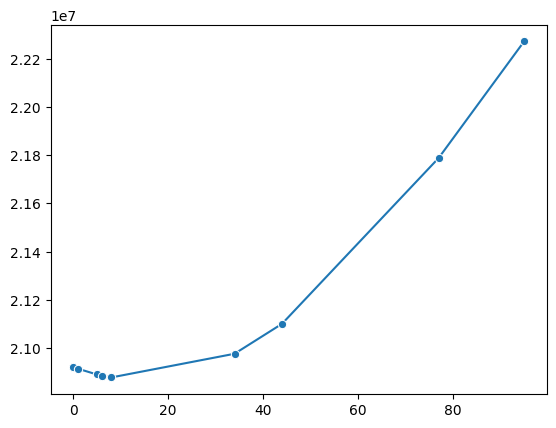

In [27]:
alpha = [0, 0.00003, 1, 5, 8, 34, 6, 95, 44, 77]
mses = []

for a in alpha:
    lasso_model = Lasso(alpha=a)
    lasso_model.fit(X_train, y_train)

    y_pred = lasso_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f"MSE for alpha {a}: ", mse)
    mses.append(mse)

sns.lineplot(x=alpha, y=mses, marker="o")

In [28]:
from sklearn.linear_model import LassoCV
alphas = [0, 0.00003, 1, 5, 8, 34, 6, 95, 44, 77]

lasso_cv_model = LassoCV(
    alphas=alphas,
    cv=10,
    max_iter=100000,
    random_state=42
)

lasso_cv_model.fit(X_train, y_train)

print("Best Alpha: ", lasso_cv_model.alpha_)
y_pred = lasso_cv_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("mse= ", mse)
print("s2: ", r2)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 11692149225.756516, tolerance: 13949811.7701018
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent wi

Best Alpha:  0.0
mse=  20922607.93807076
s2:  0.8652316979531686


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.281e+10, tolerance: 1.544e+07 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
